# Assignment 3 — Standard KAN Experiments

This notebook implements the standard KAN component of the project. It evaluates whether KAN can learn selected Feynman symbolic regression equations and recover interpretable symbolic expressions.

The standard KAN results will later be compared against:

1. MLP baseline  
2. KAN 2.0 / MultKAN  

The evaluation focuses on:

- clean-data prediction accuracy
- training stability across random seeds
- noise robustness
- symbolic recovery

## 1. Setup

This section installs PyKAN and imports the required Python packages.

In [18]:
!pip install pykan -q

import os
import time
import traceback
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from kan import *
from kan.utils import ex_round

## 2. Reproducibility and device setup

This section sets the random seeds and selects GPU if available.

In [19]:
torch.set_default_dtype(torch.float64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEEDS = [12, 18, 25, 34, 42]
NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1]

SELECTED_EQUATIONS = [
    "I_6_2",
    "I_14_3",
    "I_18_4",
    "I_29_16",
    "I_9_18"
]

DATA_DIR = "Assign3/data"

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Device: cpu


## 3. Dataset loading

The generated Feynman datasets are loaded here. Each selected equation has clean train, validation and test splits, plus noisy training files for robustness experiments.

Training files change depending on the noise level. Validation and test files remain clean for all experiments.


In [20]:
!wget "https://drive.google.com/uc?export=download&id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk" -O "dataA3.zip"
!unzip -o -q dataA3.zip

metadata = pd.read_csv("Assign3/data/selected_equations_metadata.csv", index_col="safe_name")
metadata.loc[SELECTED_EQUATIONS]

--2026-05-21 14:57:24--  https://drive.google.com/uc?export=download&id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk
Resolving drive.google.com (drive.google.com)... 74.125.137.100, 74.125.137.113, 74.125.137.101, ...
Connecting to drive.google.com (drive.google.com)|74.125.137.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk&export=download [following]
--2026-05-21 14:57:25--  https://drive.usercontent.google.com/download?id=12X6DEdfMB99GPJpWAgORZrlEuuc5uIEk&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.101.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12845323 (12M) [application/octet-stream]
Saving to: ‘dataA3.zip’

dataA3.zip          100%[===================>]  12.25M  61.0MB/s  

,equation,formula,difficulty,n_variables,variables,lows,highs,n_train,n_val,n_test
safe_name,,,,,,,,,,
I_6_2,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),easy,2,"sigma, theta","1.0, 1.0","3.0, 3.0",10000,2000,2000
I_14_3,I.14.3,m*g*z,easy,3,"m, g, z","1.0, 1.0, 1.0","5.0, 5.0, 5.0",10000,2000,2000
I_18_4,I.18.4,(m1*r1+m2*r2)/(m1+m2),medium,4,"m1, m2, r1, r2","1.0, 1.0, 1.0, 1.0","5.0, 5.0, 5.0, 5.0",10000,2000,2000
I_29_16,I.29.16,sqrt(x1**2+x2**2-2*x1*x2*cos(theta1-theta2)),medium,4,"x1, x2, theta1, theta2","1.0, 1.0, 1.0, 1.0","5.0, 5.0, 5.0, 5.0",10000,2000,2000
I_9_18,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),hard,9,"m1, m2, G, x1, x2, y1, y2, z1, z2","1.0, 1.0, 1.0, 3.0, 1.0, 3.0, 1.0, 3.0, 1.0","2.0, 2.0, 2.0, 4.0, 2.0, 4.0, 2.0, 4.0, 2.0",10000,2000,2000


## 4. Selected equations and KAN hyperparameters

Each equation uses the grid size and spline order selected from the earlier standard KAN experiments.

The five selected equations cover easy, medium and hard symbolic regression cases.

In [21]:
KAN_CONFIGS = {
    "I_6_2":   {"grid": 3,  "k": 3, "hidden_width": 2},
    "I_14_3":  {"grid": 3,  "k": 4, "hidden_width": 2},
    "I_18_4":  {"grid": 10, "k": 3, "hidden_width": 2},
    "I_29_16": {"grid": 5,  "k": 3, "hidden_width": 2},
    "I_9_18":  {"grid": 10, "k": 3, "hidden_width": 2},
}

selected_metadata = metadata.loc[SELECTED_EQUATIONS]
selected_metadata[["equation", "formula", "difficulty", "n_variables", "n_train", "n_val", "n_test"]]

,equation,formula,difficulty,n_variables,n_train,n_val,n_test
safe_name,,,,,,,
I_6_2,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),easy,2,10000,2000,2000
I_14_3,I.14.3,m*g*z,easy,3,10000,2000,2000
I_18_4,I.18.4,(m1*r1+m2*r2)/(m1+m2),medium,4,10000,2000,2000
I_29_16,I.29.16,sqrt(x1**2+x2**2-2*x1*x2*cos(theta1-theta2)),medium,4,10000,2000,2000
I_9_18,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),hard,9,10000,2000,2000


## 5. Helper functions

These functions load data, build KAN datasets, train one KAN model, evaluate clean-test MSE, and optionally extract symbolic formulas.

PyKAN uses the keys `test_input` and `test_label` during fitting. In this notebook, those correspond to the validation set. The final clean test set is kept separate and evaluated after training.

In [22]:
def noise_file_name(noise_sigma):
    noise_map = {
        0.0: "train_noise_0p0.csv",
        0.01: "train_noise_0p01.csv",
        0.05: "train_noise_0p05.csv",
        0.1: "train_noise_0p1.csv",
    }

    if noise_sigma not in noise_map:
        raise ValueError(f"Noise sigma must be one of {list(noise_map.keys())}")

    return noise_map[noise_sigma]


def load_kan_data(equation_name, noise_sigma=0.0):
    """
    Load one equation dataset for standard KAN.

    Training data may be clean or noisy.
    Validation and test data are always clean.
    """

    eq_dir = os.path.join(DATA_DIR, equation_name)

    train_path = os.path.join(eq_dir, noise_file_name(noise_sigma))
    val_path = os.path.join(eq_dir, "val_clean.csv")
    test_path = os.path.join(eq_dir, "test_clean.csv")

    if not os.path.exists(train_path):
        raise FileNotFoundError(f"Missing train file: {train_path}")
    if not os.path.exists(val_path):
        raise FileNotFoundError(f"Missing val file: {val_path}")
    if not os.path.exists(test_path):
        raise FileNotFoundError(f"Missing test file: {test_path}")

    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    x_cols = [c for c in train_df.columns if c != "y"]

    X_train = train_df[x_cols].to_numpy().astype(np.float64)
    y_train = train_df["y"].to_numpy().astype(np.float64).reshape(-1, 1)

    X_val = val_df[x_cols].to_numpy().astype(np.float64)
    y_val = val_df["y"].to_numpy().astype(np.float64).reshape(-1, 1)

    X_test = test_df[x_cols].to_numpy().astype(np.float64)
    y_test = test_df["y"].to_numpy().astype(np.float64).reshape(-1, 1)

    dataset = {
        "train_input": torch.tensor(X_train, dtype=torch.float64, device=device),
        "train_label": torch.tensor(y_train, dtype=torch.float64, device=device),
        "test_input": torch.tensor(X_val, dtype=torch.float64, device=device),
        "test_label": torch.tensor(y_val, dtype=torch.float64, device=device),
    }

    test_input = torch.tensor(X_test, dtype=torch.float64, device=device)
    test_label = torch.tensor(y_test, dtype=torch.float64, device=device)

    return dataset, test_input, test_label, x_cols


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def tensor_list_to_float_list(values):
    """
    Convert PyKAN loss outputs into ordinary Python floats.
    """
    clean_values = []

    for v in values:
        if isinstance(v, torch.Tensor):
            clean_values.append(float(v.detach().cpu().numpy()))
        else:
            clean_values.append(float(v))

    return clean_values


def evaluate_on_clean_test(model, test_input, test_label):
    """
    Evaluate a trained KAN model on the clean held-out test set.
    """
    model.eval()

    with torch.no_grad():
        y_pred = model(test_input)
        mse = torch.mean((y_pred - test_label) ** 2).item()

    return mse

## 6. Single-run standard KAN training function

This function trains one standard KAN model for one equation, one seed and one training-noise level.

The training sequence follows the earlier standard KAN notebook:

1. Adam training with sparsity regularisation  
2. Pruning  
3. LBFGS optimisation  
4. Grid refinement  
5. Final LBFGS optimisation  

Refinement increases the KAN grid resolution after the model has learned an initial coarse representation. This can improve function approximation before the final optimisation stage.

In [23]:
def train_kan_single_run(
    equation_name,
    seed,
    noise_sigma=0.0,
    adam_steps=50,
    lbfgs_steps_1=50,
    lbfgs_steps_2=50,
    lamb=0.001,
    do_prune=True,
    do_refine=True,
    extract_symbolic=False
):
    """
    Train standard KAN for one equation, one seed, and one noise level.
    """

    start_time = time.time()

    result = {
        "equation": equation_name,
        "method": "KAN",
        "seed": seed,
        "noise_sigma": noise_sigma,
        "grid": np.nan,
        "k": np.nan,
        "hidden_width": np.nan,
        "val_mse": np.nan,
        "test_mse": np.nan,
        "params": np.nan,
        "training_time_sec": np.nan,
        "diverged": True,
        "symbolic_expression": "",
        "symbolic_success": False,
        "error_message": "",
    }

    train_losses = []
    val_losses = []
    model = None

    try:
        set_seed(seed)

        dataset, test_input, test_label, x_cols = load_kan_data(
            equation_name=equation_name,
            noise_sigma=noise_sigma
        )

        n_vars = len(x_cols)

        config = KAN_CONFIGS[equation_name]
        grid = config["grid"]
        k = config["k"]
        hidden_width = config["hidden_width"]

        result["grid"] = grid
        result["k"] = k
        result["hidden_width"] = hidden_width

        model = KAN(
            width=[n_vars, hidden_width, 1],
            grid=grid,
            k=k,
            seed=seed,
            device=device
        )

        result["params"] = count_parameters(model)

        # Stage 1: Adam with sparsity regularisation
        loss_adam = model.fit(
            dataset,
            opt="Adam",
            steps=adam_steps,
            lamb=lamb
        )

        train_losses.extend(tensor_list_to_float_list(loss_adam["train_loss"]))
        val_losses.extend(tensor_list_to_float_list(loss_adam["test_loss"]))

        # Stage 2: prune model
        if do_prune:
            try:
                model = model.prune()
            except Exception as prune_error:
                result["error_message"] += f"Prune failed: {repr(prune_error)}. Continued without pruning. "

        # Stage 3: LBFGS optimisation
        loss_lbfgs_1 = model.fit(
            dataset,
            opt="LBFGS",
            steps=lbfgs_steps_1
        )

        train_losses.extend(tensor_list_to_float_list(loss_lbfgs_1["train_loss"]))
        val_losses.extend(tensor_list_to_float_list(loss_lbfgs_1["test_loss"]))

        # Stage 4: refine grid resolution
        if do_refine:
            try:
                model = model.refine(10)
            except Exception as refine_error:
                result["error_message"] += f"Refine failed: {repr(refine_error)}. Continued without refining. "

        # Stage 5: final LBFGS optimisation
        loss_lbfgs_2 = model.fit(
            dataset,
            opt="LBFGS",
            steps=lbfgs_steps_2
        )

        train_losses.extend(tensor_list_to_float_list(loss_lbfgs_2["train_loss"]))
        val_losses.extend(tensor_list_to_float_list(loss_lbfgs_2["test_loss"]))

        # Final validation and clean test metrics
        result["val_mse"] = val_losses[-1]
        result["test_mse"] = evaluate_on_clean_test(model, test_input, test_label)

        result["diverged"] = not np.isfinite(result["test_mse"])

        # Optional symbolic extraction
        if extract_symbolic:
            try:
                model.auto_symbolic(
                    lib=[
                        "x", "x^2", "x^3", "x^4",
                        "exp", "log", "sqrt",
                        "tanh", "sin", "cos", "abs"
                    ]
                )

                symbolic_formula_tuple = model.symbolic_formula()
                symbolic_expr = ex_round(symbolic_formula_tuple[0][0], 4)

                result["symbolic_expression"] = str(symbolic_expr)
                result["symbolic_success"] = True

            except Exception as symbolic_error:
                result["symbolic_expression"] = ""
                result["symbolic_success"] = False
                result["error_message"] += f"Symbolic extraction failed: {repr(symbolic_error)}. "

    except Exception as e:
        result["error_message"] += repr(e)
        result["traceback"] = traceback.format_exc()

    result["training_time_sec"] = time.time() - start_time

    return result, train_losses, val_losses, model

## 7. Smoke test

Before running the full experiment, a short run is performed on one easy equation to confirm that the pipeline works end-to-end.

The goal is not high accuracy yet. The goal is simply to check that:

- data loads correctly
- KAN initialises correctly
- training runs
- clean-test MSE is finite

In [24]:
smoke_result, smoke_train_losses, smoke_val_losses, smoke_model = train_kan_single_run(
    equation_name="I_6_2",
    seed=12,
    noise_sigma=0.0,
    adam_steps=5,
    lbfgs_steps_1=2,
    lbfgs_steps_2=2,
    lamb=0.001,
    do_prune=True,
    do_refine=False,
    extract_symbolic=False
)

smoke_result

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.19e-01 | test_loss: 1.21e-01 | reg: 1.54e+01 | : 100%|█| 5/5 [00:00<00:00, 10.93it/s


saving model version 0.1
saving model version 0.2


| train_loss: 1.46e-02 | test_loss: 1.47e-02 | reg: 1.28e+01 | : 100%|█| 2/2 [00:02<00:00,  1.13s/it


saving model version 0.3


| train_loss: 1.28e-02 | test_loss: 1.28e-02 | reg: 1.24e+01 | : 100%|█| 2/2 [00:03<00:00,  1.53s/it

saving model version 0.4


{'equation': 'I_6_2',
 'method': 'KAN',
 'seed': 12,
 'noise_sigma': 0.0,
 'grid': 3,
 'k': 3,
 'hidden_width': 2,
 'val_mse': 0.012797201624742974,
 'test_mse': 0.00016438194418231015,
 'params': 72,
 'training_time_sec': 5.908202171325684,
 'diverged': False,
 'symbolic_expression': '',
 'symbolic_success': False,
 'error_message': ''}

## 8. Clean-data stability experiment

Standard KAN is trained on clean data for all five equations using five random seeds.

This tests:

- clean-data prediction accuracy
- sensitivity to random initialisation
- divergence rate
- training time
- parameter count

In [25]:
clean_results_path = "results/kan_clean_results.csv"

if os.path.exists(clean_results_path):
    clean_results = pd.read_csv(clean_results_path).to_dict("records")
    completed_clean = set(
        (r["equation"], int(r["seed"]))
        for r in clean_results
    )
    print(f"Loaded {len(clean_results)} existing clean runs.")
else:
    clean_results = []
    completed_clean = set()

for equation_name in SELECTED_EQUATIONS:
    for seed in SEEDS:

        run_key = (equation_name, int(seed))

        if run_key in completed_clean:
            print(f"Skipping completed clean run: {run_key}")
            continue

        print(f"\nRunning clean KAN: equation={equation_name}, seed={seed}")

        res, train_losses, val_losses, model = train_kan_single_run(
            equation_name=equation_name,
            seed=seed,
            noise_sigma=0.0,
            adam_steps=50,
            lbfgs_steps_1=50,
            lbfgs_steps_2=50,
            lamb=0.001,
            do_prune=True,
            do_refine=True,
            extract_symbolic=False
        )

        clean_results.append(res)

        pd.DataFrame(clean_results).to_csv(
            clean_results_path,
            index=False
        )

        print({
            "equation": res["equation"],
            "seed": res["seed"],
            "test_mse": res["test_mse"],
            "val_mse": res["val_mse"],
            "diverged": res["diverged"],
            "time": res["training_time_sec"],
            "error": res["error_message"]
        })

clean_df = pd.DataFrame(clean_results)
clean_df


Running clean KAN: equation=I_6_2, seed=12
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.33e-01 | test_loss: 6.08e-02 | reg: 1.57e+01 | : 100%|█| 50/50 [00:06<00:00,  7.87it


saving model version 0.1
saving model version 0.2


| train_loss: 3.00e-03 | test_loss: 2.95e-03 | reg: 1.93e+01 | : 100%|█| 50/50 [01:01<00:00,  1.22s/


saving model version 0.3
saving model version 0.4


...

| train_loss: 1.28e-02 | test_loss: 1.29e-02 | reg: 2.16e+02 | : 100%|█| 50/50 [03:19<00:00,  3.99s/


saving model version 0.3
saving model version 0.4


| train_loss: 7.75e-03 | test_loss: 8.18e-03 | reg: 2.15e+02 | : 100%|█| 50/50 [03:22<00:00,  4.05s/

saving model version 0.5
{'equation': 'I_9_18', 'seed': 42, 'test_mse': 6.694291854736864e-05, 'val_mse': 0.008175190670390145, 'diverged': False, 'time': 417.30310702323914, 'error': ''}


,equation,method,seed,noise_sigma,grid,k,hidden_width,val_mse,test_mse,params,training_time_sec,diverged,symbolic_expression,symbolic_success,error_message
0,I_6_2,KAN,12,0.0,3,3,2,0.001111,1.356222e-06,72,158.267899,False,,False,
1,I_6_2,KAN,18,0.0,3,3,2,0.000205,3.774612e-08,72,161.100853,False,,False,
2,I_6_2,KAN,25,0.0,3,3,2,0.000636,4.570410e-07,72,154.506776,False,,False,
3,I_6_2,KAN,34,0.0,3,3,2,0.001371,2.117353e-06,72,165.034042,False,,False,
4,I_6_2,KAN,42,0.0,3,3,2,0.000130,1.685204e-08,72,159.729320,False,,False,
5,I_14_3,KAN,12,0.0,3,4,2,0.015335,1.918469e-04,104,227.279820,False,,False,
6,I_14_3,KAN,18,0.0,3,4,2,0.013597,1.880148e-04,104,223.312810,False,,False,
7,I_14_3,KAN,25,0.0,3,4,2,0.053105,1.450977e-03,104,229.999779,False,,False,
8,I_14_3,KAN,34,0.0,3,4,2,0.008324,7.150342e-05,104,227.701120,False,,False,
9,I_14_3,KAN,42,0.0,3,4,2,0.004471,2.308112e-05,104,228.891754,False,,False,


## 9. Clean-data summary and stability plots

This section aggregates clean-test MSE across the five random seeds for each equation.

A narrow spread indicates stable training, while a wide spread indicates sensitivity to random initialisation.

In [26]:
clean_summary = (
    clean_df
    .groupby(["equation", "method", "grid", "k", "hidden_width"])
    .agg(
        mean_test_mse=("test_mse", "mean"),
        std_test_mse=("test_mse", "std"),
        mean_val_mse=("val_mse", "mean"),
        std_val_mse=("val_mse", "std"),
        mean_params=("params", "mean"),
        mean_training_time_sec=("training_time_sec", "mean"),
        divergence_fraction=("diverged", "mean")
    )
    .reset_index()
)

clean_summary.to_csv("results/kan_clean_summary.csv", index=False)
clean_summary

,equation,method,grid,k,hidden_width,mean_test_mse,std_test_mse,mean_val_mse,std_val_mse,mean_params,mean_training_time_sec,divergence_fraction
0,I_14_3,KAN,3,4,2,3.850846e-04,6.003505e-04,0.018967,0.019563,104.0,227.437057,0.0
1,I_18_4,KAN,10,3,2,1.038783e-02,1.630908e-02,0.082085,0.060467,190.0,232.999080,0.0
2,I_29_16,KAN,5,3,2,4.989939e-01,1.162760e-02,0.690175,0.006422,140.0,194.726547,0.0
3,I_6_2,KAN,3,3,2,7.970428e-07,9.160691e-07,0.000691,0.000546,72.0,159.727778,0.0
4,I_9_18,KAN,10,3,2,1.180478e-04,8.689061e-05,0.010338,0.003678,380.0,376.550469,0.0


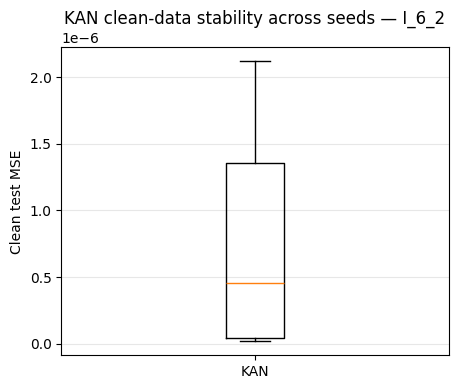

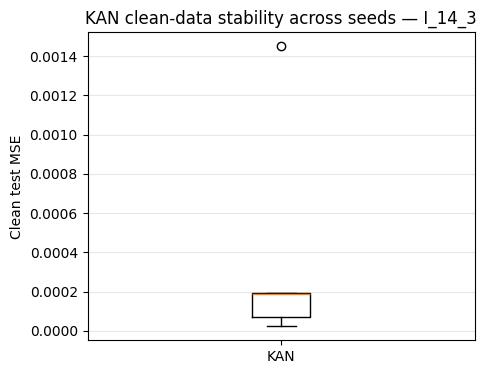

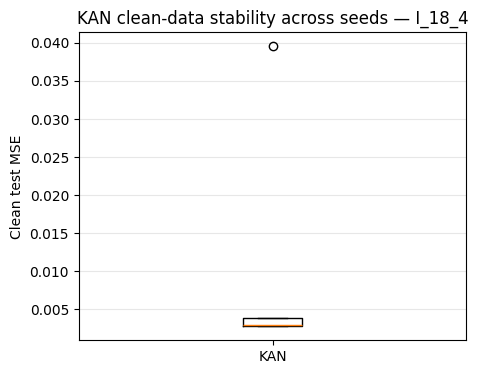

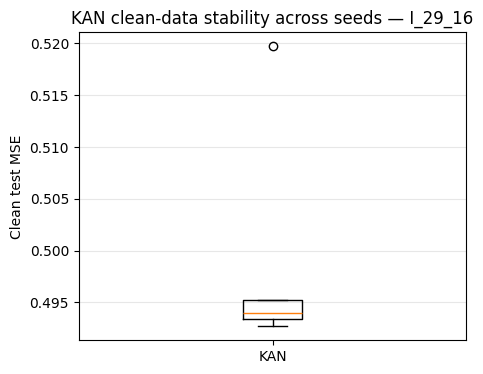

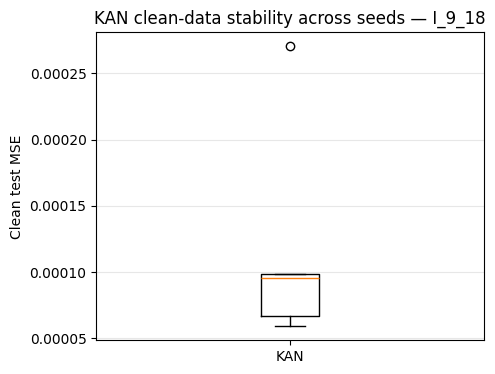

/tmp/ipykernel_1238/1798674813.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=SELECTED_EQUATIONS)


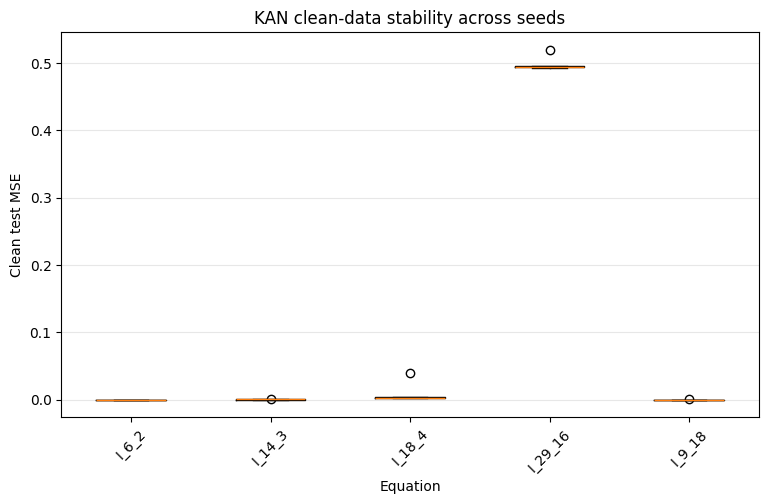

In [27]:
for equation_name in SELECTED_EQUATIONS:
    subset = clean_df[clean_df["equation"] == equation_name]

    plt.figure(figsize=(5, 4))
    plt.boxplot(subset["test_mse"].dropna())
    plt.title(f"KAN clean-data stability across seeds — {equation_name}")
    plt.ylabel("Clean test MSE")
    plt.xticks([1], ["KAN"])
    plt.grid(axis="y", alpha=0.3)
    plt.savefig(f"figures/kan_stability_{equation_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(9, 5))

data_to_plot = [
    clean_df[clean_df["equation"] == eq]["test_mse"].dropna()
    for eq in SELECTED_EQUATIONS
]

plt.boxplot(data_to_plot, labels=SELECTED_EQUATIONS)
plt.title("KAN clean-data stability across seeds")
plt.ylabel("Clean test MSE")
plt.xlabel("Equation")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.savefig("figures/kan_clean_stability_all_equations.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Noise robustness experiment

Standard KAN is trained using noisy training targets at:

\[
\sigma \in \{0, 0.01, 0.05, 0.1\}
\]

The noisy training files were already generated in the dataset preparation stage. This notebook does not add noise again. It simply loads the correct noisy training file.

Validation and test sets remain clean. Therefore, the clean-test MSE measures whether KAN learns the underlying equation rather than overfitting noisy labels.

In [28]:
noise_results_path = "results/kan_noise_results.csv"

if os.path.exists(noise_results_path):
    noise_results = pd.read_csv(noise_results_path).to_dict("records")
    completed_noise = set(
        (r["equation"], float(r["noise_sigma"]), int(r["seed"]))
        for r in noise_results
    )
    print(f"Loaded {len(noise_results)} existing noise runs.")
else:
    noise_results = []
    completed_noise = set()

for equation_name in SELECTED_EQUATIONS:
    for sigma in NOISE_LEVELS:
        for seed in SEEDS:

            run_key = (equation_name, float(sigma), int(seed))

            if run_key in completed_noise:
                print(f"Skipping completed noise run: {run_key}")
                continue

            print(f"\nRunning noisy KAN: equation={equation_name}, sigma={sigma}, seed={seed}")

            res, train_losses, val_losses, model = train_kan_single_run(
                equation_name=equation_name,
                seed=seed,
                noise_sigma=sigma,
                adam_steps=20,
                lbfgs_steps_1=20,
                lbfgs_steps_2=20,
                lamb=0.001,
                do_prune=True,
                do_refine=True,
                extract_symbolic=False
            )

            noise_results.append(res)

            pd.DataFrame(noise_results).to_csv(
                noise_results_path,
                index=False
            )

            completed_noise.add(run_key)

            print({
                "equation": res["equation"],
                "sigma": res["noise_sigma"],
                "seed": res["seed"],
                "test_mse": res["test_mse"],
                "diverged": res["diverged"],
                "time": res["training_time_sec"],
                "error": res["error_message"]
            })

noise_df = pd.DataFrame(noise_results)
noise_df

Loaded 3 existing noise runs.
Skipping completed noise run: ('I_6_2', 0.0, 12)
Skipping completed noise run: ('I_6_2', 0.0, 18)
Skipping completed noise run: ('I_6_2', 0.0, 25)

Running noisy KAN: equation=I_6_2, sigma=0.0, seed=34
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.23e-01 | test_loss: 5.08e-01 | reg: 3.11e+01 | : 100%|█| 20/20 [00:01<00:00, 10.31it


saving model version 0.1
saving model version 0.2


| train_loss: 2.76e-03 | test_loss: 2.65e-03 | reg: 1.85e+01 | : 100%|█| 20/20 [00:24<00:00,  1.24s/


saving model version 0.3
saving model version 0.4


...

| train_loss: 2.90e-02 | test_loss: 2.63e-02 | reg: 1.55e+02 | : 100%|█| 20/20 [01:17<00:00,  3.86s/


saving model version 0.3
saving model version 0.4


| train_loss: 2.01e-02 | test_loss: 1.62e-02 | reg: 1.63e+02 | : 100%|█| 20/20 [01:20<00:00,  4.02s/

saving model version 0.5
{'equation': 'I_9_18', 'sigma': 0.1, 'seed': 42, 'test_mse': 0.00024722457197888075, 'diverged': False, 'time': 163.7794463634491, 'error': ''}


,equation,method,seed,noise_sigma,grid,k,hidden_width,val_mse,test_mse,params,training_time_sec,diverged,symbolic_expression,symbolic_success,error_message,traceback
0,I_6_2,KAN,12,0.0,3,3,2,0.001944,4.269246e-06,72,66.291071,False,NaN,False,NaN,NaN
1,I_6_2,KAN,18,0.0,3,3,2,0.000396,1.614156e-07,72,60.576798,False,NaN,False,NaN,NaN
2,I_6_2,KAN,25,0.0,3,3,2,0.001381,2.028602e-06,72,61.643072,False,NaN,False,NaN,NaN
3,I_6_2,KAN,34,0.0,3,3,2,0.000747,6.988035e-07,72,64.195523,False,,False,,NaN
4,I_6_2,KAN,42,0.0,3,3,2,0.001771,3.216100e-06,72,62.553633,False,,False,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,I_9_18,KAN,12,0.1,10,3,2,0.009375,1.054204e-04,380,145.680515,False,,False,,NaN
96,I_9_18,KAN,18,0.1,10,3,2,0.010807,1.211285e-04,380,152.758691,False,,False,,NaN
97,I_9_18,KAN,25,0.1,10,3,2,0.009466,9.283159e-05,380,157.624362,False,,False,,NaN
98,I_9_18,KAN,34,0.1,10,3,2,0.009269,8.720122e-05,380,156.198163,False,,False,,NaN


## 11. Noise robustness summary and plots

This section aggregates clean-test MSE across seeds for each training-noise level.

A flatter curve indicates stronger robustness to noisy training labels.

In [29]:
noise_summary = (
    noise_df
    .groupby(["equation", "method", "noise_sigma"])
    .agg(
        mean_test_mse=("test_mse", "mean"),
        std_test_mse=("test_mse", "std"),
        mean_val_mse=("val_mse", "mean"),
        std_val_mse=("val_mse", "std"),
        mean_params=("params", "mean"),
        mean_training_time_sec=("training_time_sec", "mean"),
        divergence_fraction=("diverged", "mean")
    )
    .reset_index()
)

noise_summary.to_csv("results/kan_noise_summary.csv", index=False)
noise_summary

,equation,method,noise_sigma,mean_test_mse,std_test_mse,mean_val_mse,std_val_mse,mean_params,mean_training_time_sec,divergence_fraction
0,I_14_3,KAN,0.00,0.003777,5.466277e-03,0.059884,0.043574,104.0,84.261259,0.0
1,I_14_3,KAN,0.01,0.002181,1.701999e-03,0.055594,0.028423,104.0,74.286680,0.2
2,I_14_3,KAN,0.05,0.010385,1.185226e-03,0.111029,0.014640,104.0,90.452464,0.0
3,I_14_3,KAN,0.10,0.030654,8.708990e-03,0.182829,0.020283,104.0,89.709012,0.0
4,I_18_4,KAN,0.00,0.012675,1.343684e-02,0.096293,0.060612,190.0,92.388665,0.0
5,I_18_4,KAN,0.01,0.011943,1.251658e-02,0.093516,0.056078,190.0,92.380376,0.0
6,I_18_4,KAN,0.05,0.007133,9.557138e-03,0.073075,0.046185,190.0,93.159527,0.0
7,I_18_4,KAN,0.10,0.007196,9.515769e-03,0.074011,0.047644,190.0,93.319416,0.0
8,I_29_16,KAN,0.00,0.478974,6.284865e-02,0.667715,0.056324,140.0,65.819067,0.2
9,I_29_16,KAN,0.01,0.678991,5.051971e-01,0.772787,0.267765,140.0,74.077847,0.0


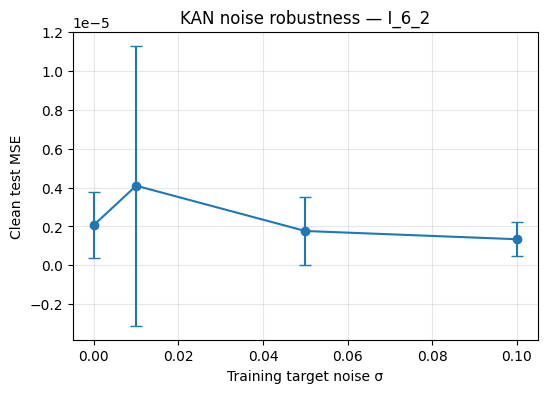

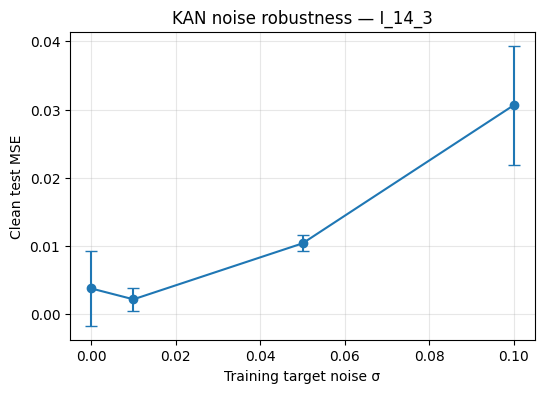

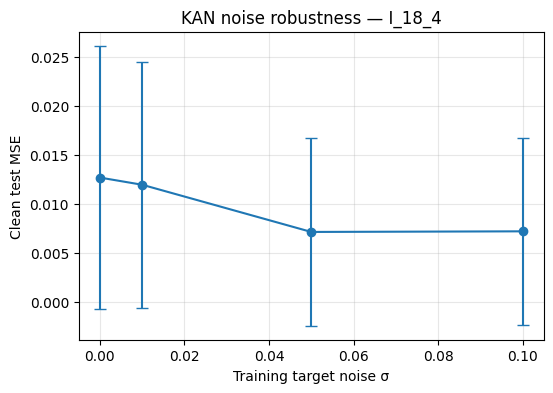

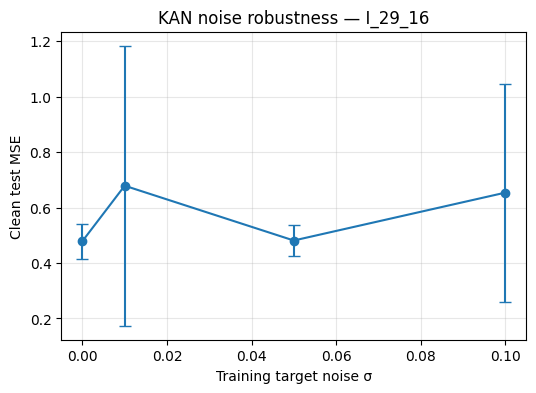

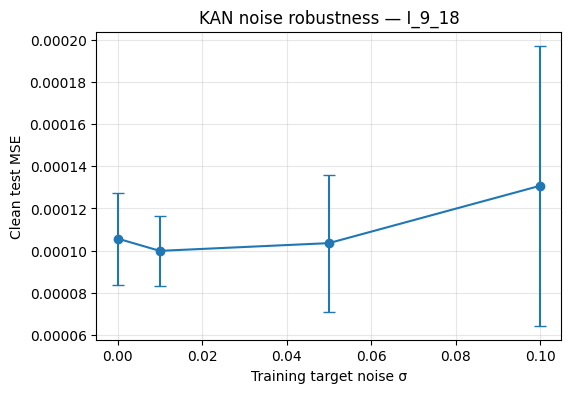

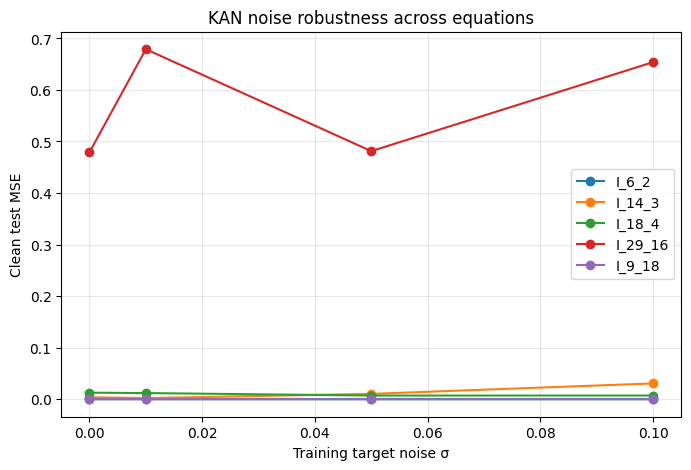

In [30]:
for equation_name in SELECTED_EQUATIONS:
    subset = noise_summary[noise_summary["equation"] == equation_name]

    plt.figure(figsize=(6, 4))
    plt.errorbar(
        subset["noise_sigma"],
        subset["mean_test_mse"],
        yerr=subset["std_test_mse"],
        marker="o",
        capsize=4
    )

    plt.title(f"KAN noise robustness — {equation_name}")
    plt.xlabel("Training target noise σ")
    plt.ylabel("Clean test MSE")
    plt.grid(alpha=0.3)
    plt.savefig(f"figures/kan_noise_robustness_{equation_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(8, 5))

for equation_name in SELECTED_EQUATIONS:
    subset = noise_summary[noise_summary["equation"] == equation_name]

    plt.plot(
        subset["noise_sigma"],
        subset["mean_test_mse"],
        marker="o",
        label=equation_name
    )

plt.title("KAN noise robustness across equations")
plt.xlabel("Training target noise σ")
plt.ylabel("Clean test MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/kan_noise_robustness_all_equations.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Symbolic extraction

The best clean-data KAN run for each equation is retrained and PyKAN symbolic extraction is attempted.

Symbolic extraction is done only for clean-data models, because the goal is to recover the underlying Feynman equation, not an expression fitted to noisy labels.

In [31]:
best_clean_runs = (
    clean_df
    .sort_values("test_mse")
    .groupby("equation")
    .head(1)
    .reset_index(drop=True)
)

best_clean_runs[["equation", "seed", "test_mse", "val_mse", "params"]]

,equation,seed,test_mse,val_mse,params
0,I_6_2,42,1.685204e-08,0.000130,72
1,I_14_3,42,2.308112e-05,0.004471,104
2,I_9_18,12,5.903305e-05,0.007554,380
3,I_18_4,25,2.761173e-03,0.051852,190
4,I_29_16,25,4.926975e-01,0.685824,140


In [32]:
symbolic_results_path = "results/kan_symbolic_extraction_raw.csv"

symbolic_results = []

for _, row in best_clean_runs.iterrows():
    equation_name = row["equation"]
    seed = int(row["seed"])

    print(f"\nSymbolic extraction for equation={equation_name}, seed={seed}")

    res, train_losses, val_losses, model = train_kan_single_run(
        equation_name=equation_name,
        seed=seed,
        noise_sigma=0.0,
        adam_steps=50,
        lbfgs_steps_1=50,
        lbfgs_steps_2=50,
        lamb=0.001,
        do_prune=True,
        do_refine=True,
        extract_symbolic=True
    )

    symbolic_results.append(res)

    pd.DataFrame(symbolic_results).to_csv(
        symbolic_results_path,
        index=False
    )

    print({
        "equation": res["equation"],
        "seed": res["seed"],
        "test_mse": res["test_mse"],
        "symbolic_success": res["symbolic_success"],
        "symbolic_expression": res["symbolic_expression"],
        "error": res["error_message"]
    })

symbolic_raw = pd.DataFrame(symbolic_results)
symbolic_raw


Symbolic extraction for equation=I_6_2, seed=42
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.55e-02 | test_loss: 4.59e-02 | reg: 1.31e+01 | : 100%|█| 50/50 [00:04<00:00, 11.85it


saving model version 0.1
saving model version 0.2


| train_loss: 4.73e-04 | test_loss: 4.88e-04 | reg: 1.59e+01 | : 100%|█| 50/50 [01:01<00:00,  1.24s/


saving model version 0.3
saving model version 0.4


...

| train_loss: 7.26e-01 | test_loss: 7.13e-01 | reg: 4.91e+01 | : 100%|█| 50/50 [01:23<00:00,  1.67s/


saving model version 0.3
saving model version 0.4


| train_loss: 6.84e-01 | test_loss: 6.86e-01 | reg: 5.03e+01 | : 100%|█| 50/50 [01:50<00:00,  2.21s/


saving model version 0.5
fixing (0,0,0) with x^2, r2=0.9722947766543202, c=2
fixing (0,0,1) with x, r2=0.9833517844307976, c=1
fixing (0,1,0) with x^2, r2=0.9609005031415101, c=2
fixing (0,1,1) with x, r2=0.9809375521154166, c=1
fixing (0,2,0) with x, r2=0.9057958574719429, c=1
fixing (0,2,1) with x, r2=0.909662622405945, c=1
fixing (0,3,0) with x, r2=0.9113844987804961, c=1
fixing (0,3,1) with x, r2=0.9066190405773545, c=1
fixing (1,0,0) with exp, r2=0.9952069448519443, c=2
fixing (1,1,0) with x, r2=0.9885369535910895, c=1
saving model version 0.6
{'equation': 'I_29_16', 'seed': 25, 'test_mse': 0.49287952098352983, 'symbolic_success': True, 'symbolic_expression': '0.5686*x_1 + 0.5667*x_2 + 4.6546*x_3 + 4.658*x_4 - 2.1756*exp(0.3118*x_3 + 0.3122*x_4 - 0.e-4*(9.7994 - 3.264*x_2)**2 - 0.e-4*(9.9212 - 3.2644*x_1)**2) - 11.4949', 'error': ''}


,equation,method,seed,noise_sigma,grid,k,hidden_width,val_mse,test_mse,params,training_time_sec,diverged,symbolic_expression,symbolic_success,error_message
0,I_6_2,KAN,42,0.0,3,3,2,0.000208,3.772810e-08,72,346.434406,False,0.0027*(8.3348 - 2.2327*x_1)**2 - 0.2605*cos(3...,True,
1,I_14_3,KAN,42,0.0,3,4,2,0.004447,2.295258e-05,104,476.747867,False,0.0435*(10.7743*log(5.0*x_1 + 0.02) + 10.7703*...,True,
2,I_9_18,KAN,12,0.0,10,3,2,0.007555,5.906535e-05,380,926.711032,False,0.0384*(6.7454*x_3 - 3.8848)**0.596*exp(0.6908...,True,
3,I_18_4,KAN,25,0.0,10,3,2,0.052029,2.757077e-03,190,544.244897,False,2.6101*exp(0.0036*x_1 + 0.0005*x_2 - 38.1296*e...,True,
4,I_29_16,KAN,25,0.0,5,3,2,0.686190,4.928795e-01,140,513.480715,False,0.5686*x_1 + 0.5667*x_2 + 4.6546*x_3 + 4.658*x...,True,


## 13. Symbolic recovery table

Extracted expressions are compared against the Feynman ground-truth equations and labelled as:

- pass: algebraically equivalent to the ground truth
- partial: captures some correct structure but is not fully equivalent
- fail: wrong, overly complex, or not interpretable as the target equation

Low test MSE is not sufficient for symbolic recovery. The extracted expression must match the ground-truth formula in an interpretable way.

In [33]:
ground_truth_map = {
    "I_6_2": "exp(-(theta/sigma)^2/2)/(sqrt(2*pi)*sigma)",
    "I_14_3": "m*g*z",
    "I_18_4": "(m1*r1 + m2*r2)/(m1 + m2)",
    "I_29_16": "sqrt(x1^2 + x2^2 - 2*x1*x2*cos(theta1 - theta2))",
    "I_9_18": "G*m1*m2/((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)"
}

symbolic_recovery = symbolic_raw.copy()
symbolic_recovery["ground_truth"] = symbolic_recovery["equation"].map(ground_truth_map)

symbolic_recovery["recovery_label"] = "fail"
symbolic_recovery["failure_diagnosis"] = (
    "Extracted expression is not clearly algebraically equivalent to the ground-truth Feynman equation."
)

symbolic_recovery[
    [
        "equation",
        "ground_truth",
        "symbolic_expression",
        "symbolic_success",
        "recovery_label",
        "failure_diagnosis",
        "test_mse"
    ]
]

,equation,ground_truth,symbolic_expression,symbolic_success,recovery_label,failure_diagnosis,test_mse
0,I_6_2,exp(-(theta/sigma)^2/2)/(sqrt(2*pi)*sigma),0.0027*(8.3348 - 2.2327*x_1)**2 - 0.2605*cos(3...,True,fail,Extracted expression is not clearly algebraica...,3.772810e-08
1,I_14_3,m*g*z,0.0435*(10.7743*log(5.0*x_1 + 0.02) + 10.7703*...,True,fail,Extracted expression is not clearly algebraica...,2.295258e-05
2,I_9_18,G*m1*m2/((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2),0.0384*(6.7454*x_3 - 3.8848)**0.596*exp(0.6908...,True,fail,Extracted expression is not clearly algebraica...,5.906535e-05
3,I_18_4,(m1*r1 + m2*r2)/(m1 + m2),2.6101*exp(0.0036*x_1 + 0.0005*x_2 - 38.1296*e...,True,fail,Extracted expression is not clearly algebraica...,2.757077e-03
4,I_29_16,sqrt(x1^2 + x2^2 - 2*x1*x2*cos(theta1 - theta2)),0.5686*x_1 + 0.5667*x_2 + 4.6546*x_3 + 4.658*x...,True,fail,Extracted expression is not clearly algebraica...,4.928795e-01


### Manual symbolic recovery edits

After inspecting the extracted symbolic expressions above, manually adjust the recovery labels if needed.

For example, if an expression captures part of the correct structure but is not exactly equivalent, label it as `partial`.

In [34]:
# Example manual edit.
# Change these after inspecting the actual symbolic expressions.

symbolic_recovery.loc[
    symbolic_recovery["equation"] == "I_14_3",
    ["recovery_label", "failure_diagnosis"]
] = [
    "partial",
    "Expression captures some product-like structure, but is not a clean exact recovery of m*g*z."
]

symbolic_recovery.to_csv("results/kan_symbolic_recovery.csv", index=False)

symbolic_recovery[
    [
        "equation",
        "ground_truth",
        "symbolic_expression",
        "recovery_label",
        "failure_diagnosis",
        "test_mse"
    ]
]

,equation,ground_truth,symbolic_expression,recovery_label,failure_diagnosis,test_mse
0,I_6_2,exp(-(theta/sigma)^2/2)/(sqrt(2*pi)*sigma),0.0027*(8.3348 - 2.2327*x_1)**2 - 0.2605*cos(3...,fail,Extracted expression is not clearly algebraica...,3.772810e-08
1,I_14_3,m*g*z,0.0435*(10.7743*log(5.0*x_1 + 0.02) + 10.7703*...,partial,Expression captures some product-like structur...,2.295258e-05
2,I_9_18,G*m1*m2/((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2),0.0384*(6.7454*x_3 - 3.8848)**0.596*exp(0.6908...,fail,Extracted expression is not clearly algebraica...,5.906535e-05
3,I_18_4,(m1*r1 + m2*r2)/(m1 + m2),2.6101*exp(0.0036*x_1 + 0.0005*x_2 - 38.1296*e...,fail,Extracted expression is not clearly algebraica...,2.757077e-03
4,I_29_16,sqrt(x1^2 + x2^2 - 2*x1*x2*cos(theta1 - theta2)),0.5686*x_1 + 0.5667*x_2 + 4.6546*x_3 + 4.658*x...,fail,Extracted expression is not clearly algebraica...,4.928795e-01


## 14. Export results

This section exports the standard KAN result tables and figures so they can be combined with the MLP and KAN 2.0 results.

In [35]:
# Export final CSVs again, just to be safe.
clean_df.to_csv("results/kan_clean_results.csv", index=False)
clean_summary.to_csv("results/kan_clean_summary.csv", index=False)

noise_df.to_csv("results/kan_noise_results.csv", index=False)
noise_summary.to_csv("results/kan_noise_summary.csv", index=False)

symbolic_raw.to_csv("results/kan_symbolic_extraction_raw.csv", index=False)
symbolic_recovery.to_csv("results/kan_symbolic_recovery.csv", index=False)

print("Standard KAN CSV export complete.")

Standard KAN CSV export complete.


In [36]:
import shutil

shutil.make_archive("standard_kan_results", "zip", "results")
shutil.make_archive("standard_kan_figures", "zip", "figures")

print("Created:")
print("standard_kan_results.zip")
print("standard_kan_figures.zip")

Created:
standard_kan_results.zip
standard_kan_figures.zip


In [37]:
from google.colab import files

files.download("standard_kan_results.zip")
files.download("standard_kan_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>